In [150]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [151]:
data = pd.read_csv('/kaggle/input/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results/athlete_events.csv')
data.head(10)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN


In [152]:
data.isnull().sum()


ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [153]:
data.shape

(271116, 15)

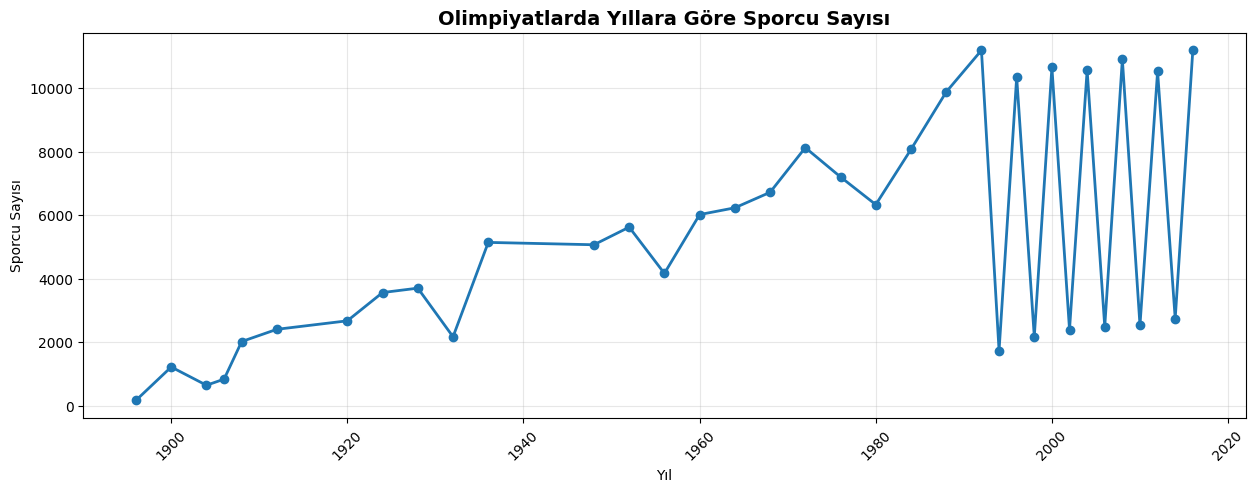

In [154]:
atlet_yıllar_göre = data.groupby('Year')['ID'].nunique()
plt.figure(figsize=(15,5))
plt.plot(atlet_yıllar_göre.index, atlet_yıllar_göre.values, marker = 'o', linewidth=2)
plt.title('Olimpiyatlarda Yıllara Göre Sporcu Sayısı', fontsize=14, fontweight='bold')
plt.xlabel('Yıl')
plt.ylabel('Sporcu Sayısı')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

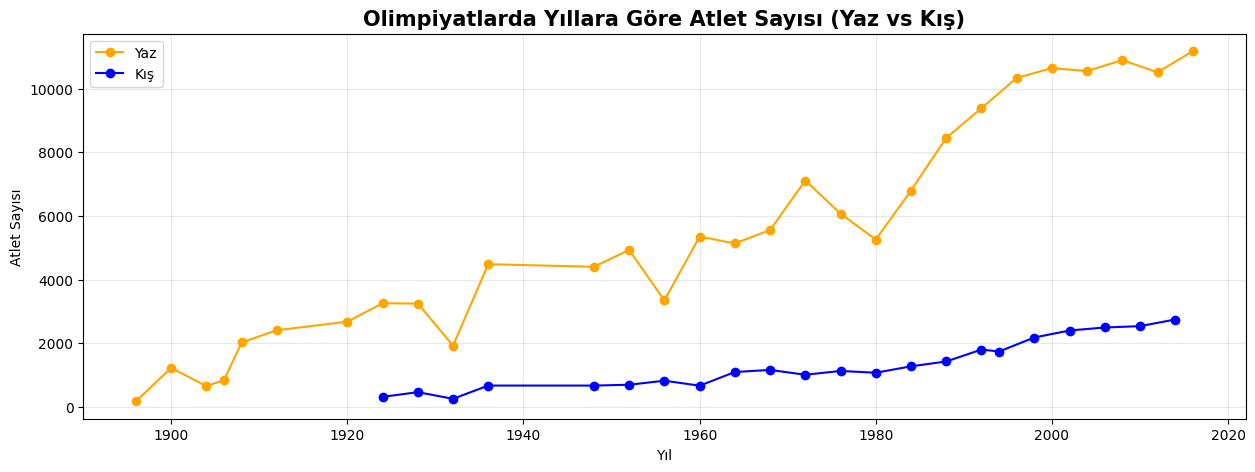

In [155]:
winter = data[data['Season'] == 'Winter'].groupby('Year')['ID'].nunique()
summer = data[data['Season'] == 'Summer'].groupby('Year')['ID'].nunique()

plt.figure(figsize=(15,5))
plt.plot(summer.index, summer.values, marker='o', label='Yaz', color='Orange')
plt.plot(winter.index, winter.values, marker='o', label='Kış', color='Blue')
plt.title('Olimpiyatlarda Yıllara Göre Atlet Sayısı (Yaz vs Kış)', fontsize=15, fontweight='bold')
plt.xlabel('Yıl')
plt.ylabel('Atlet Sayısı')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

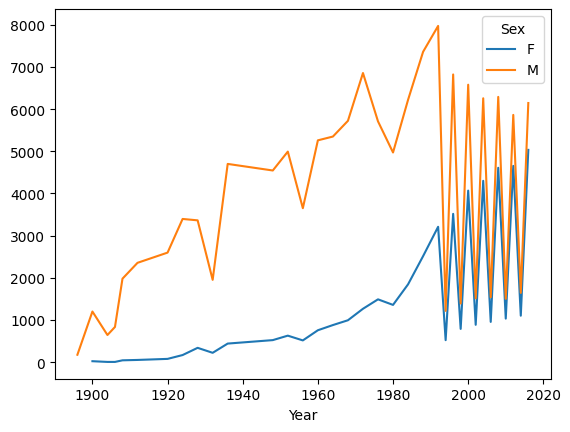

In [156]:
genderr_year = data.groupby(['Year', 'Sex'])['ID'].nunique().unstack()
genderr_year.plot()
plt.show()

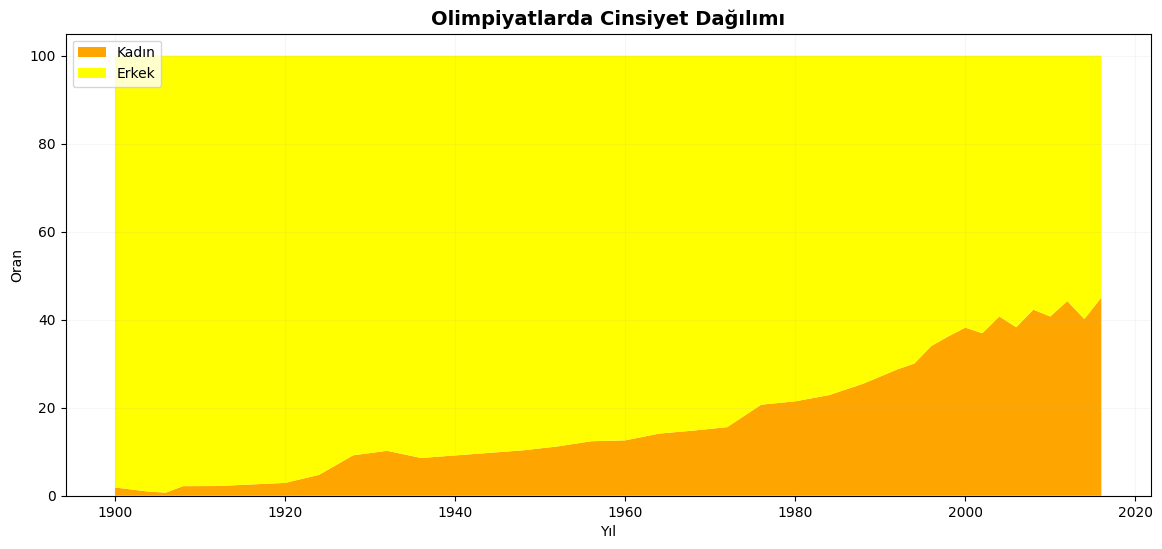

In [157]:
genderr_year_yüzde = genderr_year.div(genderr_year.sum(axis=1), axis=0) * 100
plt.figure(figsize=(14,6))
plt.stackplot(genderr_year_yüzde.index, genderr_year_yüzde['F'], genderr_year_yüzde['M'], labels = ['Kadın', 'Erkek'], colors = ['orange', 'yellow'])
plt.title('Olimpiyatlarda Cinsiyet Dağılımı', fontsize = 14, fontweight = 'bold')
plt.xlabel('Yıl')
plt.ylabel('Oran')
plt.legend(loc='upper left')
plt.grid(alpha=0.1)
plt.show()

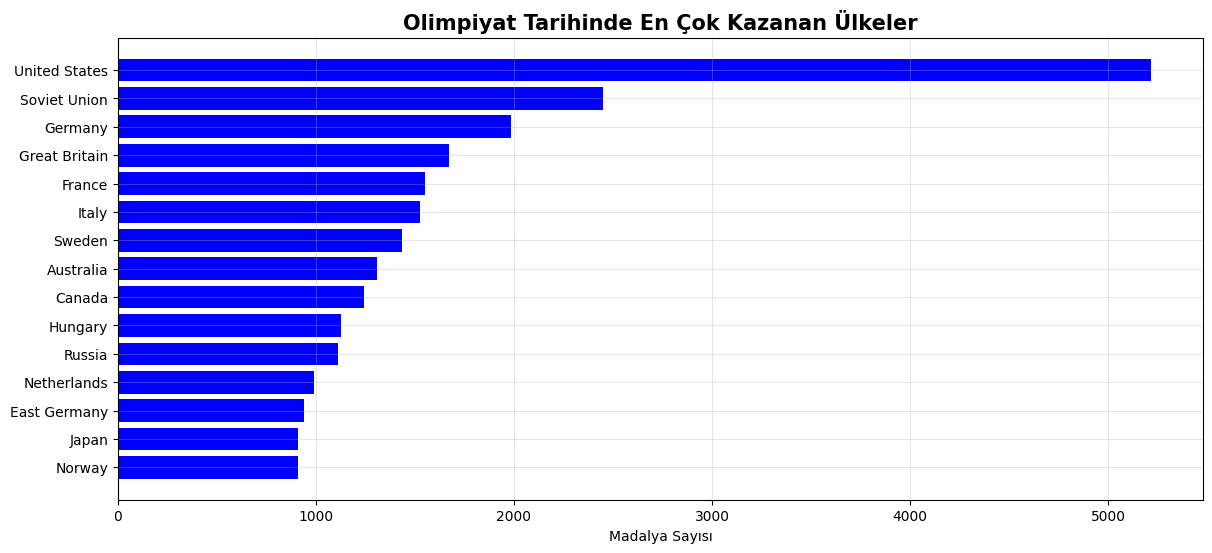

In [158]:
madalyalar = data[data['Medal'].notna()]
top_country = madalyalar['Team'].value_counts().head(15)
plt.figure(figsize=(14,6))

plt.barh(top_country.index, top_country.values, color='blue')
plt.gca().invert_yaxis()

plt.title('Olimpiyat Tarihinde En Çok Kazanan Ülkeler', fontsize=15, fontweight = 'bold')
plt.xlabel('Madalya Sayısı')
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_57/3738812767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='Sport', y='Height', palette='Set2')


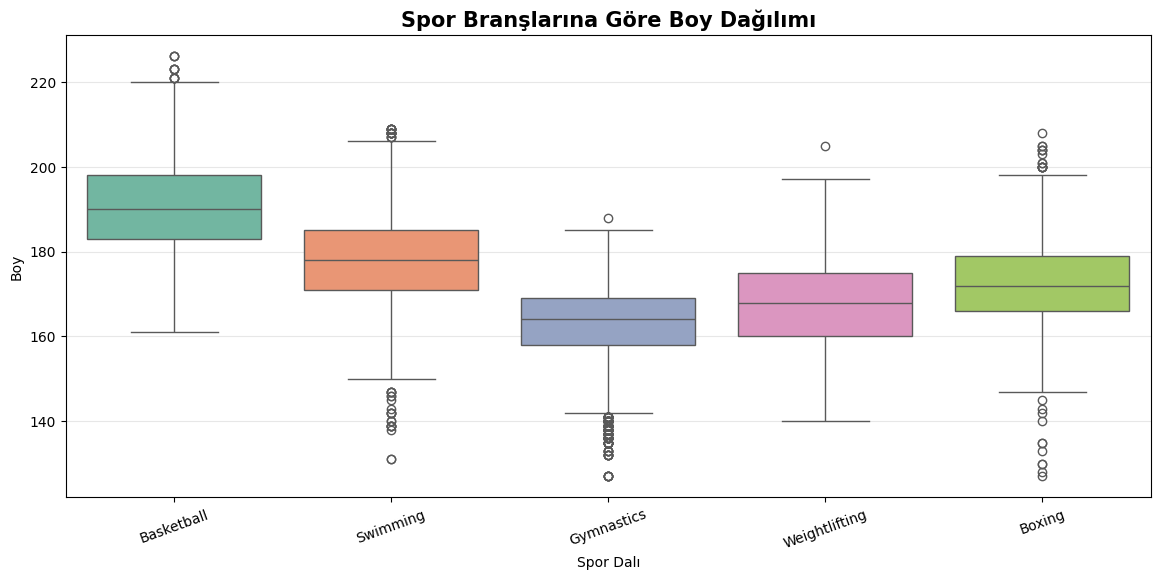

In [159]:
sporlar = ['Basketball', 'Gymnastics', 'Swimming', 'Boxing', 'Weightlifting', 'Marathon']

df_filtered = data[data['Sport'].isin(sporlar)]


plt.figure(figsize=(14,6))
sns.boxplot(data=df_filtered, x='Sport', y='Height', palette='Set2')
plt.title('Spor Branşlarına Göre Boy Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('Spor Dalı')
plt.ylabel('Boy')
plt.xticks(rotation=20)
plt.grid(alpha=0.3, axis='y')
plt.show()

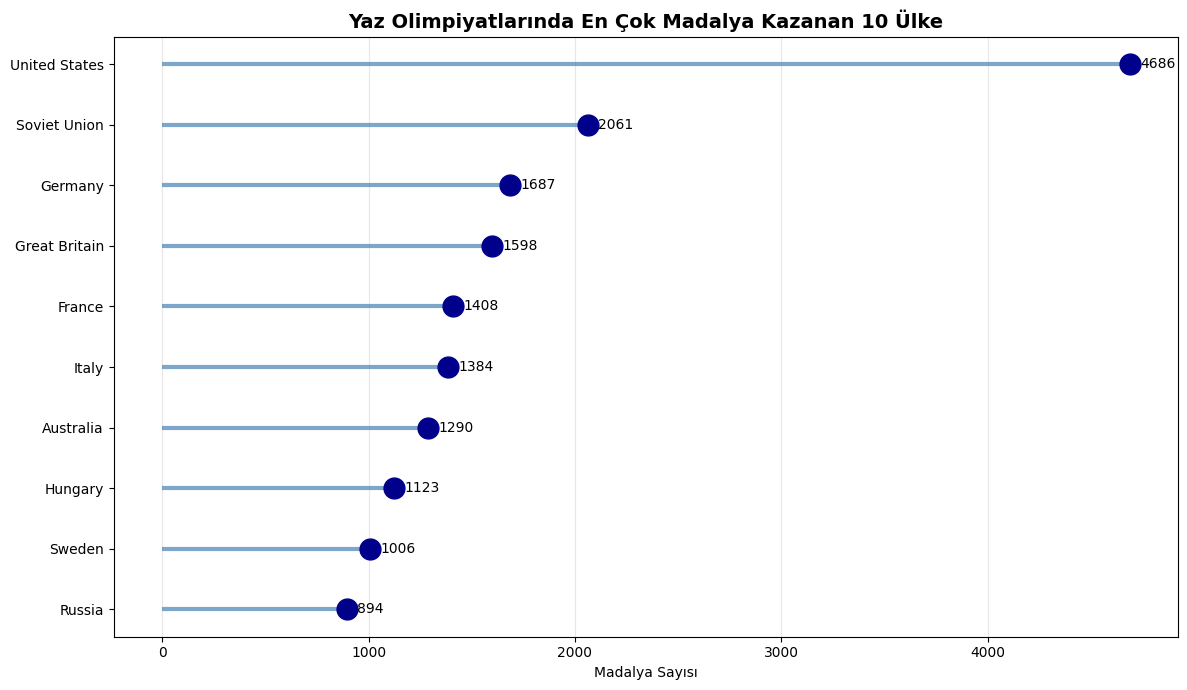

In [160]:
yaz_madalya = data[(data['Season'] == 'Summer') & (data['Medal'].notna())]
top10 = yaz_madalya['Team'].value_counts().head(10)

plt.figure(figsize=(12, 7))


plt.hlines(y=top10.index, xmin=0, xmax=top10.values, 
           color='steelblue', alpha=0.7, linewidth=3)


plt.plot(top10.values, top10.index, 'o', 
         markersize=15, color='darkblue')


for i, value in enumerate(top10.values):
    plt.text(value + 50, i, str(value), va='center', fontsize=10)

plt.gca().invert_yaxis()
plt.title('Yaz Olimpiyatlarında En Çok Madalya Kazanan 10 Ülke', 
          fontsize=14, fontweight='bold')
plt.xlabel('Madalya Sayısı')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [161]:
data.head(12)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN


In [162]:
top_sports = data['Sport'].value_counts().head().index.tolist()
top_sports

['Athletics', 'Gymnastics', 'Swimming', 'Shooting', 'Cycling']

In [163]:
df = data[data['Sport'].isin(top_sports)].copy()
df.shape

(110833, 15)

In [164]:
df.isnull().sum()

ID            0
Name          0
Sex           0
Age        4319
Height    24469
Weight    25963
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     99069
dtype: int64

In [165]:
df = df.drop(['ID', 'Name', 'Event' ,'Games', 'City', 'Medal', 'NOC'], axis=1)
df.head()

,Sex,Age,Height,Weight,Team,Year,Season,Sport
26,F,18.0,168.0,NaN,Netherlands,1932,Summer,Athletics
27,F,18.0,168.0,NaN,Netherlands,1932,Summer,Athletics
29,M,26.0,NaN,NaN,Finland,1952,Summer,Swimming
35,M,22.0,NaN,NaN,Finland,1912,Summer,Swimming
36,M,22.0,NaN,NaN,Finland,1912,Summer,Swimming


In [166]:
top20_teams = df['Team'].value_counts().head(20).index.to_list()

In [167]:
df['Team'] = np.where(df['Team'].isin(top20_teams), df['Team'], 'Other')
df['Team'].nunique()

21

In [168]:
df.describe()

,Age,Height,Weight,Year
count,106514.000000,86364.000000,84870.00000,110833.000000
mean,24.388559,173.637360,67.36824,1974.572699
std,6.073790,10.693512,13.96699,31.237329
min,10.000000,127.000000,25.00000,1896.000000
25%,20.000000,167.000000,58.00000,1956.000000
50%,23.000000,174.000000,66.00000,1980.000000
75%,27.000000,181.000000,75.00000,2000.000000
max,72.000000,213.000000,165.00000,2016.000000


In [169]:
df['Age'] = df.groupby('Sport')['Age'].transform(lambda x: x.fillna(x.mean()))
df['Height'] = df.groupby('Sport')['Height'].transform(lambda x: x.fillna(x.mean()))
df['Weight'] = df.groupby('Sport')['Weight'].transform(lambda x: x.fillna(x.mean()))

df.isnull().sum()

Sex       0
Age       0
Height    0
Weight    0
Team      0
Year      0
Season    0
Sport     0
dtype: int64

In [170]:
df.head()

,Sex,Age,Height,Weight,Team,Year,Season,Sport
26,F,18.0,168.000000,69.249287,Netherlands,1932,Summer,Athletics
27,F,18.0,168.000000,69.249287,Netherlands,1932,Summer,Athletics
29,M,26.0,178.562454,70.588492,Finland,1952,Summer,Swimming
35,M,22.0,178.562454,70.588492,Finland,1912,Summer,Swimming
36,M,22.0,178.562454,70.588492,Finland,1912,Summer,Swimming


In [171]:
df['Sex'] = df['Sex'].map({"F": 0, 'M': 1})
df['Season'] = df['Season'].map({'Summer': 1, 'Winter': 0})

df = pd.get_dummies(df, columns=['Team'])

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sport_Encoded'] = le.fit_transform(df['Sport'])

In [172]:
df.head()

,Sex,Age,Height,Weight,Year,Season,Sport,Team_Canada,Team_China,Team_Czechoslovakia,...,Team_Other,Team_Poland,Team_Romania,Team_Russia,Team_Soviet Union,Team_Spain,Team_Sweden,Team_Switzerland,Team_United States,Sport_Encoded
26,0,18.0,168.000000,69.249287,1932,1,Athletics,False,False,False,...,False,False,False,False,False,False,False,False,False,0
27,0,18.0,168.000000,69.249287,1932,1,Athletics,False,False,False,...,False,False,False,False,False,False,False,False,False,0
29,1,26.0,178.562454,70.588492,1952,1,Swimming,False,False,False,...,False,False,False,False,False,False,False,False,False,4
35,1,22.0,178.562454,70.588492,1912,1,Swimming,False,False,False,...,False,False,False,False,False,False,False,False,False,4
36,1,22.0,178.562454,70.588492,1912,1,Swimming,False,False,False,...,False,False,False,False,False,False,False,False,False,4


In [173]:
df.shape

(110833, 28)

In [176]:
df.drop('Sport', axis=1, inplace=True)

In [178]:
df.columns.to_list()

['Sex',
 'Age',
 'Height',
 'Weight',
 'Year',
 'Season',
 'Team_Canada',
 'Team_China',
 'Team_Czechoslovakia',
 'Team_Finland',
 'Team_France',
 'Team_Germany',
 'Team_Great Britain',
 'Team_Hungary',
 'Team_Italy',
 'Team_Japan',
 'Team_Netherlands',
 'Team_Other',
 'Team_Poland',
 'Team_Romania',
 'Team_Russia',
 'Team_Soviet Union',
 'Team_Spain',
 'Team_Sweden',
 'Team_Switzerland',
 'Team_United States',
 'Sport_Encoded']

In [182]:
from sklearn.model_selection import train_test_split

X = df.drop('Sport_Encoded', axis=1)
y = df['Sport_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (88666, 26)
Test: (22167, 26)


In [183]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [188]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


models = {

    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "Logistic Regression" : LogisticRegression()
}

def evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test):
    results = []

    for name, model in models.items():

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)


        accuracy = accuracy_score(y_test, y_pred)
        confusion = confusion_matrix(y_test, y_pred)
        classification = classification_report(y_test, y_pred)


        results.append({
            "name": name,
            "accuracy": accuracy
        })


        print(f"\nMODEL: {name}")
        print("=" * 40)
        print("Karmaşıklık Matrisi:")
        print(confusion)
        print("\nSınıflandırma Raporu:")
        print(classification)
        print(f"Accuracy: {accuracy:.4f}")


    return pd.DataFrame(results).sort_values(by=['accuracy'], ascending=False)


summary_table = evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test)


MODEL: Random Forest
Karmaşıklık Matrisi:
[[6751  223  131  109  511]
 [ 506 1428   45   52  141]
 [  10    0 5331    0    0]
 [ 276   54   29 1892   39]
 [ 312   44   36   17 4230]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      7725
           1       0.82      0.66      0.73      2172
           2       0.96      1.00      0.98      5341
           3       0.91      0.83      0.87      2290
           4       0.86      0.91      0.88      4639

    accuracy                           0.89     22167
   macro avg       0.88      0.85      0.86     22167
weighted avg       0.88      0.89      0.88     22167

Accuracy: 0.8856

MODEL: XGBoost
Karmaşıklık Matrisi:
[[6397  101  383  122  722]
 [ 785  908  169   80  230]
 [ 238   26 5018    5   54]
 [ 429   47   80 1662   72]
 [ 738   37  138   20 3706]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.74      0.

In [191]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
params = {

    'n_estimators': randint(100, 500),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2']
    
}

search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),params,n_iter=10,cv=3,scoring='accuracy',n_jobs=-1,random_state=42,verbose=1)

search.fit(X_train_scaled, y_train)
print("Best params:", search.best_params_)
print("Best score:", search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 413}
Best score: 0.8172241754900668
